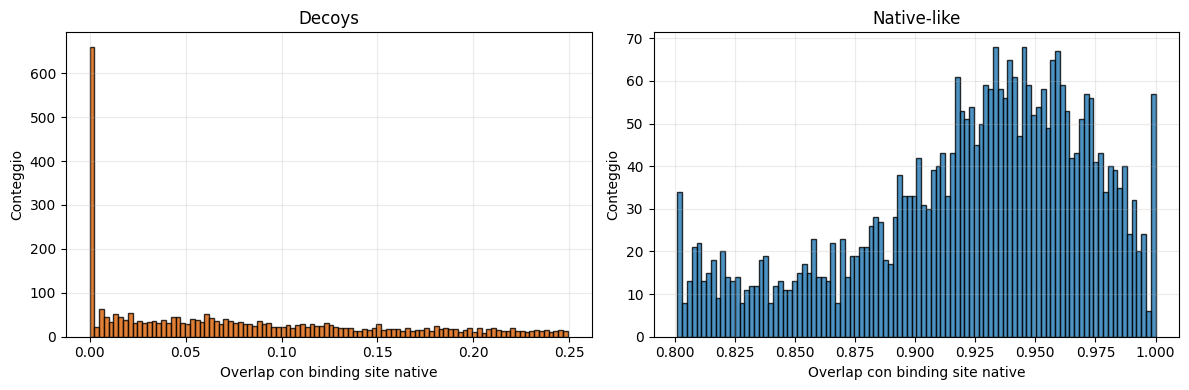

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

json_paths = {
    "decoys": Path("input_files/Jac_idx_decoy.json"),
    "native_like": Path("input_files/Jac_idx_native_like.json"),
}

with json_paths["decoys"].open("r", encoding="utf-8") as handle:
    decoy_values = json.load(handle)

with json_paths["native_like"].open("r", encoding="utf-8") as handle:
    native_like_values = json.load(handle)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(decoy_values, bins=100, color="#d95f02", alpha=0.8, edgecolor="black")
axes[0].set_title("Decoys")
axes[0].set_xlabel("Overlap con binding site native")
axes[0].set_ylabel("Conteggio")
axes[0].grid(alpha=0.25)

axes[1].hist(native_like_values, bins=100, color="#1f77b4", alpha=0.8, edgecolor="black")
axes[1].set_title("Native-like")
axes[1].set_xlabel("Overlap con binding site native")
axes[1].set_ylabel("Conteggio")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

nativelike_raw_df = pd.read_csv('output_files/nativelike/nativelike.csv')
decoys_raw_df = pd.read_csv('output_files/decoys/decoys.csv')
all_nativelike_df = pd.read_csv('output_files/native/all_native.csv')
native_like_jindex_df = pd.read_csv('output_files/nativelike/nativelike_j_index.csv')
native_like_jindex_df['complex name'] = native_like_jindex_df['complex name'].astype(str)
native_like_jindex_df['J index'] = pd.to_numeric(native_like_jindex_df['J index'], errors='coerce')

N_RINGS = 10
RDF_DETECTOR_PREFIXES = ('physical_ring', 'zernike_ring', 'roughness_ring')
RDF_COL_PATTERNS = (
    'physical_ring{rid}_mean',
    'physical_ring{rid}_uncertainty',
    'zernike_ring{rid}_mean',
    'zernike_ring{rid}_uncertainty',
    'roughness_ring{rid}',
)


def prepare_datasets_for_jmax(jmax):
    nativelike_df = nativelike_raw_df.assign(
        _complex_key=nativelike_raw_df['complex_name'].astype(str).str.replace('-', '_', regex=False)
    ).merge(
        native_like_jindex_df.rename(columns={'complex name': '_complex_key', 'J index': 'j_index'}),
        on='_complex_key',
        how='inner',
    )
    nativelike_df = nativelike_df.loc[nativelike_df['j_index'] <= float(jmax)].copy()
    nativelike_df['complex_prefix'] = nativelike_df['complex_name'].astype(str).str.split('-').str[0].str[:4]

    decoys_df = decoys_raw_df.copy()
    decoys_df['complex_prefix'] = decoys_df['complex_name'].astype(str).str.split('-').str[0].str[:4]

    common_complexes = sorted(set(nativelike_df['complex_prefix'].dropna()).intersection(set(decoys_df['complex_prefix'].dropna())))
    nativelike_df = nativelike_df.loc[nativelike_df['complex_prefix'].isin(common_complexes)].copy()
    decoys_df = decoys_df.loc[decoys_df['complex_prefix'].isin(common_complexes)].copy()

    if len(nativelike_df) != len(decoys_df):
        raise ValueError(f'Filtered datasets have different sizes at jmax={jmax}: {len(nativelike_df)} vs {len(decoys_df)}')

    nativelike_df = nativelike_df.drop(columns=['_complex_key', 'j_index', 'complex_prefix'])
    decoys_df = decoys_df.drop(columns=['complex_prefix'])
    return nativelike_df, decoys_df, len(common_complexes)


def add_ring_mean_columns(df, radius_col='radius', n_rings=N_RINGS):
    df = df.copy()
    radius_values = pd.to_numeric(df[radius_col], errors='coerce')
    for ring_id in range(1, n_rings + 1):
        df[f'ring{ring_id}_mean_A'] = radius_values * (ring_id - 0.5) / n_rings
    return df


def build_feature_table(df, use_radius_limit=False, radius_limit=20.0):
    feature_columns = ['complex_name', 'dataset_label', 'physical_mean', 'roughness']
    if df.empty:
        return pd.DataFrame(columns=feature_columns)

    grouped_cols = ['radius'] + [f'physical_ring{i}_mean' for i in range(1, 11)] + [f'roughness_ring{i}' for i in range(1, 11)]
    grouped = df.groupby(['complex_name', 'dataset_label'], as_index=False)[grouped_cols].mean()
    rows = []

    for _, row in grouped.iterrows():
        radius = pd.to_numeric(pd.Series([row['radius']]), errors='coerce').iloc[0]
        if not np.isfinite(radius) or radius <= 0:
            continue

        if use_radius_limit:
            valid_rings = [rid for rid in range(1, N_RINGS + 1) if radius * rid / float(N_RINGS) <= float(radius_limit)]
        else:
            valid_rings = list(range(1, N_RINGS + 1))

        physical_values = []
        roughness_values = []
        for rid in valid_rings:
            physical_value = pd.to_numeric(pd.Series([row[f'physical_ring{rid}_mean']]), errors='coerce').iloc[0]
            roughness_value = pd.to_numeric(pd.Series([row[f'roughness_ring{rid}']]), errors='coerce').iloc[0]
            if np.isfinite(physical_value):
                physical_values.append(float(physical_value))
            if np.isfinite(roughness_value):
                roughness_values.append(float(roughness_value))

        if not physical_values or not roughness_values:
            continue

        rows.append({
            'complex_name': row['complex_name'],
            'dataset_label': row['dataset_label'],
            'physical_mean': float(np.mean(physical_values)),
            'roughness': float(np.mean(roughness_values)),
        })

    if not rows:
        return pd.DataFrame(columns=feature_columns)
    return pd.DataFrame(rows, columns=feature_columns)


def _grouped_oof_scores(clean_df, n_splits=5, random_state=42):
    X = clean_df[['physical_mean', 'roughness']].to_numpy(dtype=float)
    y = (clean_df['dataset_label'] == 'decoy').astype(int).to_numpy()
    groups = clean_df['complex_name'].astype(str).to_numpy()

    unique_groups = pd.Series(groups).nunique()
    if unique_groups < 2 or np.unique(y).size < 2:
        return None

    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    y_score = np.full(shape=y.shape, fill_value=np.nan, dtype=float)
    fold_auc = []
    fold_acc = []

    max_splits = min(int(n_splits), int(unique_groups))
    successful_split = False
    for current_splits in range(max_splits, 1, -1):
        splitter = StratifiedGroupKFold(
            n_splits=current_splits,
            shuffle=True,
            random_state=random_state,
        )
        y_score[:] = np.nan
        fold_auc.clear()
        fold_acc.clear()

        try:
            for train_idx, test_idx in splitter.split(X, y, groups=groups):
                model.fit(X[train_idx], y[train_idx])
                probs = model.predict_proba(X[test_idx])[:, 1]
                y_score[test_idx] = probs

                y_test = y[test_idx]
                if np.unique(y_test).size == 2:
                    # Fold-wise AUC quantifies split-to-split variability.
                    ranks = probs.argsort().argsort().astype(float) + 1.0
                    n_pos = np.sum(y_test == 1)
                    n_neg = np.sum(y_test == 0)
                    auc_fold = (np.sum(ranks[y_test == 1]) - (n_pos * (n_pos + 1) / 2.0)) / (n_pos * n_neg)
                    fold_auc.append(float(auc_fold))

                preds = (probs >= 0.5).astype(int)
                fold_acc.append(float(np.mean(preds == y_test)))

            successful_split = True
            break
        except ValueError:
            continue

    if not successful_split:
        return None

    finite_mask = np.isfinite(y_score)
    if finite_mask.sum() == 0:
        return None

    y_valid = y[finite_mask]
    score_valid = y_score[finite_mask]
    if np.unique(y_valid).size < 2:
        return None

    ranks_valid = score_valid.argsort().argsort().astype(float) + 1.0
    n_pos_valid = np.sum(y_valid == 1)
    n_neg_valid = np.sum(y_valid == 0)
    auc_oof = (np.sum(ranks_valid[y_valid == 1]) - (n_pos_valid * (n_pos_valid + 1) / 2.0)) / (n_pos_valid * n_neg_valid)
    y_pred_valid = (score_valid >= 0.5).astype(int)
    acc_oof = float(np.mean(y_pred_valid == y_valid))

    return {
        'auc_oof': float(auc_oof),
        'acc_oof': acc_oof,
        'auc_std': float(np.std(fold_auc)) if fold_auc else np.nan,
        'acc_std': float(np.std(fold_acc)) if fold_acc else np.nan,
    }


def evaluate_separation(feature_df):
    required_columns = ['complex_name', 'physical_mean', 'roughness', 'dataset_label']
    if feature_df.empty or not set(required_columns).issubset(feature_df.columns):
        return {
            'n': int(feature_df.shape[0]),
            'auc_mean': np.nan,
            'auc_std': np.nan,
            'accuracy_mean': np.nan,
            'accuracy_std': np.nan,
        }

    clean_df = feature_df.dropna(subset=required_columns).copy()
    if clean_df.empty or clean_df['dataset_label'].nunique() < 2:
        return {
            'n': int(clean_df.shape[0]),
            'auc_mean': np.nan,
            'auc_std': np.nan,
            'accuracy_mean': np.nan,
            'accuracy_std': np.nan,
        }

    oof_result = _grouped_oof_scores(clean_df)
    if oof_result is None:
        return {
            'n': int(clean_df.shape[0]),
            'auc_mean': np.nan,
            'auc_std': np.nan,
            'accuracy_mean': np.nan,
            'accuracy_std': np.nan,
        }

    return {
        'n': int(clean_df.shape[0]),
        'auc_mean': float(oof_result['auc_oof']),
        'auc_std': float(oof_result['auc_std']),
        'accuracy_mean': float(oof_result['acc_oof']),
        'accuracy_std': float(oof_result['acc_std']),
    }


print('native_like_jindex rows:', native_like_jindex_df.shape[0])
print('nativelike_raw_df:', nativelike_raw_df.shape)
print('decoys_raw_df:', decoys_raw_df.shape)
print('all_nativelike_df:', all_nativelike_df.shape)

native_like_jindex rows: 3256
nativelike_raw_df: (3726, 63)
decoys_raw_df: (3134, 63)
all_nativelike_df: (3731, 63)


    jmax  n_complexes  auc_all_rings  accuracy_all_rings  auc_radius_20  accuracy_radius_20
0.800000            0            NaN                 NaN            NaN                 NaN
0.801005            0            NaN                 NaN            NaN                 NaN
0.802010           14       0.464286            0.500000       0.382653            0.357143
0.803015           21       0.310658            0.357143       0.360544            0.357143
0.804020           24       0.392361            0.354167       0.463542            0.458333
0.805025           29       0.382878            0.431034       0.357907            0.396552
0.806030           31       0.345473            0.370968       0.364204            0.467742
0.807035           37       0.428780            0.432432       0.402484            0.418919
0.808040           47       0.267542            0.351064       0.333635            0.361702
0.809045           53       0.386258            0.367925       0.343183         

/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtua

min complexes: 0
max complexes: 2665
best AUC all rings at jmax = 1.0
best accuracy all rings at jmax = 1.0


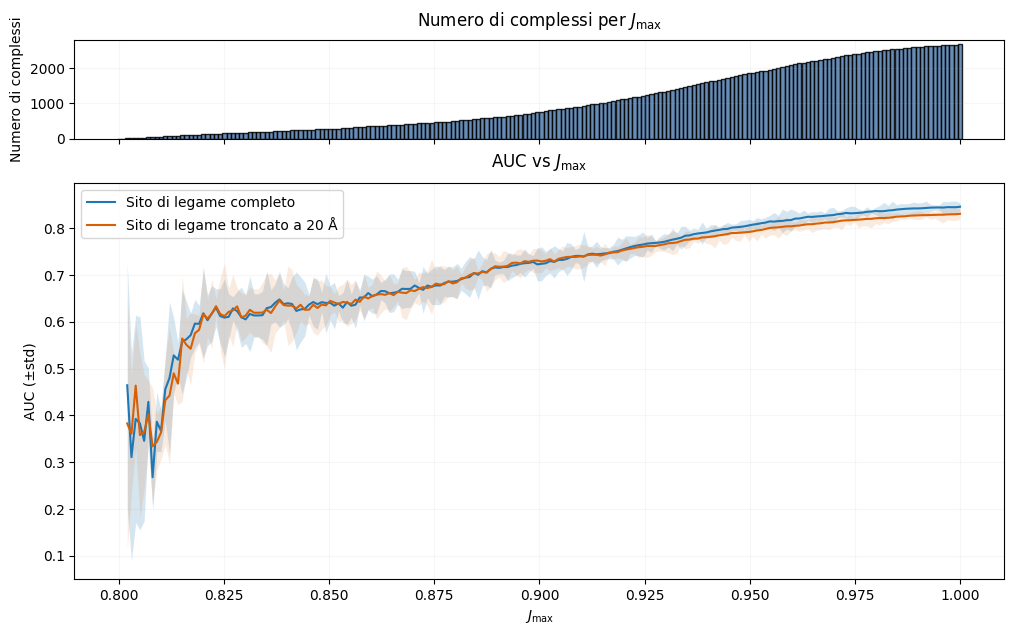

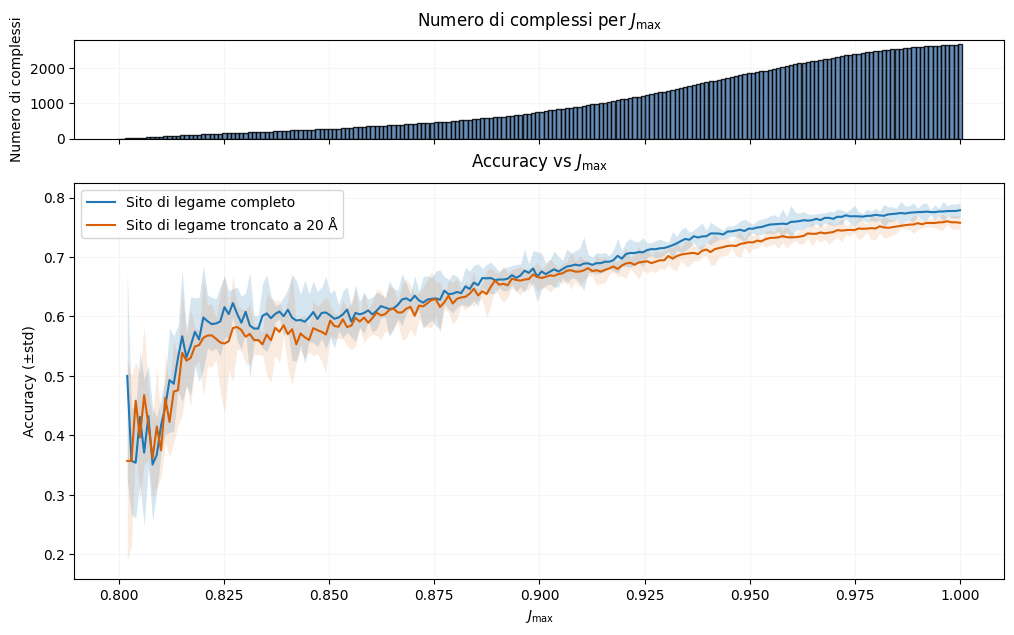

In [3]:
jmax_values = np.linspace(0.8, 1.0, 200, endpoint=True)
sweep_rows = []

for jmax in jmax_values:
    nativelike_jmax_df, decoys_jmax_df, n_common = prepare_datasets_for_jmax(float(jmax))

    nativelike_jmax_df = add_ring_mean_columns(nativelike_jmax_df)
    decoys_jmax_df = add_ring_mean_columns(decoys_jmax_df)

    nativelike_labeled = nativelike_jmax_df.copy()
    nativelike_labeled['dataset_label'] = 'nativelike'
    decoys_labeled = decoys_jmax_df.copy()
    decoys_labeled['dataset_label'] = 'decoy'

    combined_df = pd.concat([nativelike_labeled, decoys_labeled], ignore_index=True)
    feature_all_rings = build_feature_table(combined_df, use_radius_limit=False)
    feature_radius_20 = build_feature_table(combined_df, use_radius_limit=True, radius_limit=20.0)

    stats_all_rings = evaluate_separation(feature_all_rings)
    stats_radius_20 = evaluate_separation(feature_radius_20)

    sweep_rows.append({
        'jmax': float(jmax),
        'n_complexes': int(n_common),
        'auc_all_rings': stats_all_rings['auc_mean'],
        'auc_all_rings_std': stats_all_rings['auc_std'],
        'accuracy_all_rings': stats_all_rings['accuracy_mean'],
        'accuracy_all_rings_std': stats_all_rings['accuracy_std'],
        'auc_radius_20': stats_radius_20['auc_mean'],
        'auc_radius_20_std': stats_radius_20['auc_std'],
        'accuracy_radius_20': stats_radius_20['accuracy_mean'],
        'accuracy_radius_20_std': stats_radius_20['accuracy_std'],
    })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df[['jmax', 'n_complexes', 'auc_all_rings', 'accuracy_all_rings', 'auc_radius_20', 'accuracy_radius_20']].to_string(index=False))

def plot_metric_with_complex_marginal(data, metric_all_col, metric_radius_col, title, y_label, color_all, color_radius, path, metric_std_all_col=None, metric_std_radius_col=None):
    fig, (ax_top, ax_main) = plt.subplots(
        2,
        1,
        figsize=(12, 7),
        sharex=True,
        gridspec_kw={'height_ratios': [1, 4], 'hspace': 0.18},
    )

    data_sorted = data.sort_values('jmax')

    ax_top.bar(data_sorted['jmax'], data_sorted['n_complexes'], width=0.001, color='#4c78a8', alpha=0.85, edgecolor='black')
    ax_top.set_title(r'Numero di complessi per $J_{\max}$', pad=10)
    ax_top.set_ylabel('Numero di complessi')
    ax_top.grid(alpha=0.1)

    if metric_std_all_col is not None:
        ax_main.fill_between(
            data_sorted['jmax'],
            data_sorted[metric_all_col] - data_sorted[metric_std_all_col],
            data_sorted[metric_all_col] + data_sorted[metric_std_all_col],
            color=color_all,
            alpha=0.18,
            linewidth=0,
        )
    sns.lineplot(data=data_sorted, x='jmax', y=metric_all_col, marker=None, ax=ax_main, color=color_all, label='Sito di legame completo')

    if metric_std_radius_col is not None:
        ax_main.fill_between(
            data_sorted['jmax'],
            data_sorted[metric_radius_col] - data_sorted[metric_std_radius_col],
            data_sorted[metric_radius_col] + data_sorted[metric_std_radius_col],
            color=color_radius,
            alpha=0.12,
            linewidth=0,
        )
    sns.lineplot(data=data_sorted, x='jmax', y=metric_radius_col, marker=None, ax=ax_main, color=color_radius, label='Sito di legame troncato a 20 Å')
    ax_main.set_title(title, pad=12)
    ax_main.set_xlabel(r'$J_{\max}$')
    ax_main.set_ylabel(y_label)
    ax_main.grid(alpha=0.1)
    plt.savefig(path, dpi=300, bbox_inches='tight')
plot_metric_with_complex_marginal(
    sweep_df,
    metric_all_col='auc_all_rings',
    metric_radius_col='auc_radius_20',
    metric_std_all_col='auc_all_rings_std',
    metric_std_radius_col='auc_radius_20_std',
    title=r'AUC vs $J_{\max}$',
    y_label='AUC (±std)',
    color_all='#1f77b4',
    color_radius='#d95f02',
    path='discrimination/auc_vs_jmax.pdf'
)

plot_metric_with_complex_marginal(
    sweep_df,
    metric_all_col='accuracy_all_rings',
    metric_radius_col='accuracy_radius_20',
    metric_std_all_col='accuracy_all_rings_std',
    metric_std_radius_col='accuracy_radius_20_std',
    title=r'Accuracy vs $J_{\max}$',
    y_label='Accuracy (±std)',
    color_all='#1f77b4',
    color_radius='#d95f02',
    path='discrimination/accuracy_vs_jmax.pdf'
)

print('min complexes:', int(sweep_df['n_complexes'].min()))
print('max complexes:', int(sweep_df['n_complexes'].max()))
print('best AUC all rings at jmax =', float(sweep_df.loc[sweep_df['auc_all_rings'].idxmax(), 'jmax']))
print('best accuracy all rings at jmax =', float(sweep_df.loc[sweep_df['accuracy_all_rings'].idxmax(), 'jmax']))